In [ ]:
import pandas as pd 
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print(df.shape)
df.info()
df.isnull().sum()

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
import numpy as np 
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace('', np.nan), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2281.916928
std,24.559481,30.090047,2265.270398
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,402.225000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


C:\Users\My Pc\AppData\Local\Temp\ipykernel_27508\2919141898.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2')


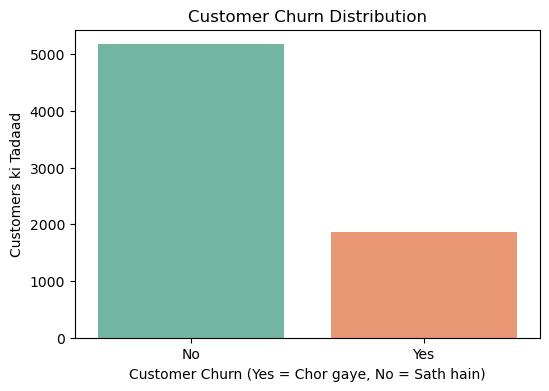

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Customer Churn Distribution')
plt.xlabel('Customer Churn (Yes = Chor gaye, No = Sath hain)')
plt.ylabel('Customers ki Tadaad')
plt.show()

C:\Users\My Pc\AppData\Local\Temp\ipykernel_27508\3827792211.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette='Pastel1')


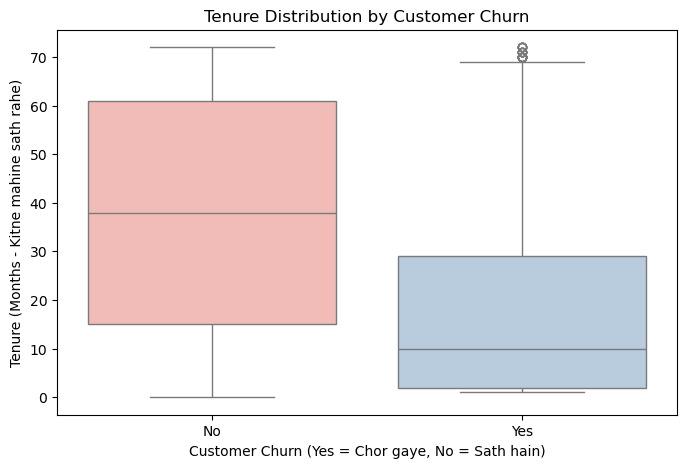

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='tenure', data=df, palette='Pastel1')
plt.title('Tenure Distribution by Customer Churn')
plt.xlabel('Customer Churn (Yes = Chor gaye, No = Sath hain)')
plt.ylabel('Tenure (Months - Kitne mahine sath rahe)')
plt.show()

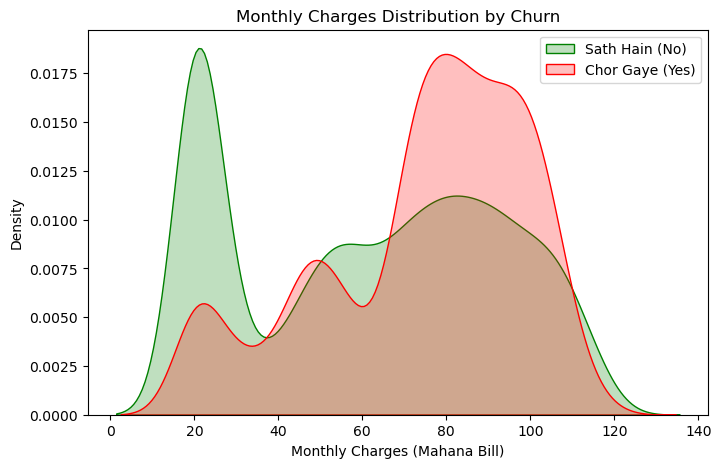

In [ ]:
plt.figure(figsize=(8, 5))
sns.kdeplot(df[df['Churn'] == 'No']['MonthlyCharges'], label='Sath Hain (No)', fill=True, color='green')
sns.kdeplot(df[df['Churn'] == 'Yes']['MonthlyCharges'], label='Chor Gaye (Yes)', fill=True, color='red')
plt.title('Monthly Charges Distribution by Churn')
plt.xlabel('Monthly Charges (Mahana Bill)')
plt.ylabel('Density')
plt.legend()
plt.show()

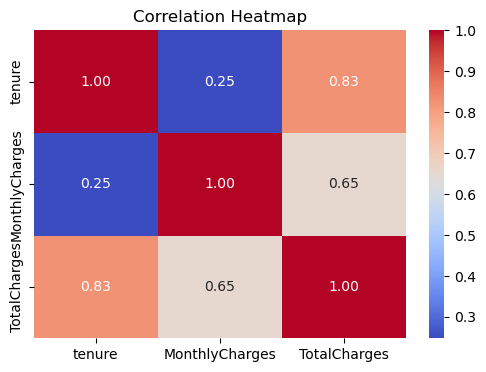

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['Partner'] = df['Partner'].map({'Yes': 1, 'No': 0})
df['Dependents'] = df['Dependents'].map({'Yes': 1, 'No': 0})
df[['Partner', 'Dependents', 'Churn']].head()

,Partner,Dependents,Churn
0,1,0,0
1,0,0,0
2,0,0,1
3,0,0,0
4,0,0,1


In [ ]:
# InternetService column ko One-Hot Encode karna
df = pd.get_dummies(df, columns=['InternetService'], drop_first=True)

# Naye bane huye columns ko check karne ke liye
df.filter(like='InternetService').head()

,InternetService_Fiber optic,InternetService_No
0,False,False
1,False,False
2,False,False
3,False,False
4,True,False


In [ ]:
# 1. Naya feature: Kya customer streaming services use karta hai?
# (Hum check kar rahe hain agar unke paas TV ya Movies mein se kuch bhi 'Yes' hai)
df['StreamingUser'] = ((df['StreamingTV'] == 'Yes') | (df['StreamingMovies'] == 'Yes')).astype(int)

# 2. Naya feature: TotalCharges ko tenure se divide karke check karte hain average behavior
df['ChargesPerMonthRatio'] = df['TotalCharges'] / (df['tenure'] + 1) # +1 isliye taake zero se divide na ho

# Check karne ke liye shuru ki 5 lines
df[['StreamingUser', 'ChargesPerMonthRatio']].head()

,StreamingUser,ChargesPerMonthRatio
0,0,14.925000
1,0,53.985714
2,0,36.050000
3,0,40.016304
4,0,50.550000


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Sirf wahi columns select karte hain jo numbers mein badal chuke hain
feature_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Partner', 'Dependents', 'StreamingUser', 'ChargesPerMonthRatio']
X = df[feature_cols]
y = df['Churn']

# 2. Data ko Train aur Test sets mein split karna (Yahan 'test_size' kar diya hai)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Logistic Regression Model banana aur train karna
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)

# 4. Predictions nikalna
y_pred = model_lr.predict(X_test)

# 5. Accuracy check karna
print("Model Accuracy:", accuracy_score(y_test, y_pred))

Model Accuracy: 0.7977288857345636


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 1. Random Forest Model banana (100 darashton wala forest)
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Model ko train karna
model_rf.fit(X_train, y_train)

# 3. Predictions nikalna
y_pred_rf = model_rf.predict(X_test)

# 4. Accuracy check karna
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.7679205110007097


In [ ]:
print("=== LOGISTIC REGRESSION REPORT ===")
print(classification_report(y_test, y_pred))

print("\n=== RANDOM FOREST REPORT ===")
print(classification_report(y_test, y_pred_rf))

=== LOGISTIC REGRESSION REPORT ===
              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1036
           1       0.68      0.45      0.54       373

    accuracy                           0.80      1409
   macro avg       0.75      0.68      0.70      1409
weighted avg       0.78      0.80      0.78      1409


=== RANDOM FOREST REPORT ===
              precision    recall  f1-score   support

           0       0.81      0.89      0.85      1036
           1       0.59      0.42      0.49       373

    accuracy                           0.77      1409
   macro avg       0.70      0.66      0.67      1409
weighted avg       0.75      0.77      0.75      1409



In [ ]:
def segment_customer(row):
    if row['tenure'] > 30 and row['MonthlyCharges'] > 70:
        return 'High Value'
    elif row['tenure'] < 12 or row['MonthlyCharges'] < 30:
        return 'Low Value'
    else:
        return 'Medium Value'
df['Customer_Segment'] = df.apply(segment_customer, axis=1)

print(df['Customer_Segment'].value_counts())

Customer_Segment
Low Value       3152
High Value      2015
Medium Value    1876
Name: count, dtype: int64


C:\Users\My Pc\AppData\Local\Temp\ipykernel_27508\1198626754.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Customer_Segment', data=df, palette='Set2', order=['High Value', 'Medium Value', 'Low Value'])


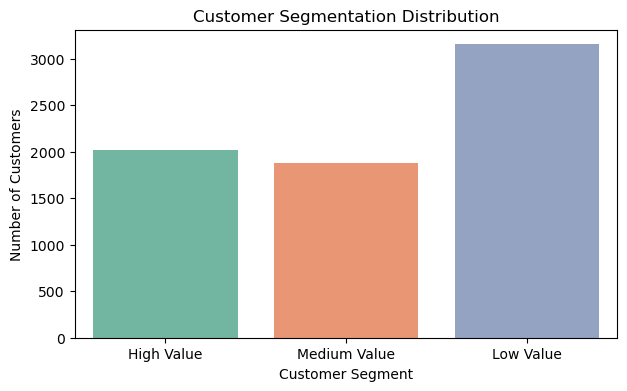

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

# Customer segments ka count plot banana
sns.countplot(x='Customer_Segment', data=df, palette='Set2', order=['High Value', 'Medium Value', 'Low Value'])

plt.title('Customer Segmentation Distribution')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.show()

In [ ]:
import numpy as np

df['Churn_Probability'] = model_lr.predict_proba(df[feature_cols])[:, 1]

def assign_risk(prob):
    if prob > 0.6:
        return 'High Risk'
    elif prob > 0.3:
        return 'Medium Risk'
    else:
        return 'Low Risk'
df['Risk_Category'] = df['Churn_Probability'].apply(assign_risk)
print(df['Risk_Category'].value_counts())
print("\n--- Shuru ke 5 customers ka risk profile ---")
print(df[['tenure', 'MonthlyCharges', 'Churn_Probability', 'Risk_Category']].head())


Risk_Category
Low Risk       4649
Medium Risk    1632
High Risk       762
Name: count, dtype: int64

--- Shuru ke 5 customers ka risk profile ---


,tenure,MonthlyCharges,Churn_Probability,Risk_Category
0,1,29.85,0.404762,Medium Risk
1,34,56.95,0.143337,Low Risk
2,2,53.85,0.529857,Medium Risk
3,45,42.30,0.060855,Low Risk
4,2,70.70,0.649240,High Risk
